Install Libraries

In [15]:
!pip install facenet-pytorch scikit-learn -q
!pip install facenet-pytorch mtcnn

In [16]:
!pip uninstall -y pillow
!pip install pillow==9.5.0
!pip install facenet-pytorch -q

Found existing installation: pillow 10.2.0
Uninstalling pillow-10.2.0:
  Successfully uninstalled pillow-10.2.0
  Using cached Pillow-9.5.0-cp312-cp312-linux_x86_64.whl
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 9.5.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


Imports

In [37]:
import os
import random
import tarfile
import itertools
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numpy.linalg import norm

import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.metrics import roc_curve, auc

Set seed for reproducibility

In [38]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Extract LFW dataset

In [39]:
tgz_path = "/content/drive/MyDrive/lfw-funneled.tgz"
extract_root = "/content/lfw"

os.makedirs(extract_root, exist_ok=True)

with tarfile.open(tgz_path, "r:gz") as tar:
    tar.extractall(path=extract_root)

print("Extraction complete.")
print("Contents of /content/lfw:", os.listdir(extract_root))

/tmp/ipykernel_12736/1223895787.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_root)


Extraction complete.
Contents of /content/lfw: ['lfw_funneled']


Define dataset path and inspect structure

In [40]:
base_path = "/content/lfw/lfw_funneled"

all_items = os.listdir(base_path)
person_folders = [p for p in all_items if os.path.isdir(os.path.join(base_path, p))]

print("Total folders (persons):", len(person_folders))

# Summary info
dataset_info = []
total_images = 0

for person in person_folders:
    person_path = os.path.join(base_path, person)
    images = [img for img in os.listdir(person_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    count = len(images)
    dataset_info.append((person, count))
    total_images += count

dataset_info.sort(key=lambda x: x[1], reverse=True)

print("Total images:", total_images)
print("\nTop 10 people with most images:")
for person, count in dataset_info[:10]:
    print(f"{person}: {count} images")

Total folders (persons): 5749
Total images: 13233

Top 10 people with most images:
George_W_Bush: 530 images
Colin_Powell: 236 images
Tony_Blair: 144 images
Donald_Rumsfeld: 121 images
Gerhard_Schroeder: 109 images
Ariel_Sharon: 77 images
Hugo_Chavez: 71 images
Junichiro_Koizumi: 60 images
Jean_Chretien: 55 images
John_Ashcroft: 53 images


Keep only valid people with at least 2 images

In [41]:
valid_people = [person for person, count in dataset_info if count >= 2]

print("People with >= 2 images:", len(valid_people))

People with >= 2 images: 1680


Select subset for experiments

In [42]:
subset_size = 200 #can incerese them

selected_people = random.sample(valid_people, subset_size)

print("Selected people:", len(selected_people))
print("Sample selected people:", selected_people[:10])

Selected people: 200
Sample selected people: ['Rita_Moreno', 'Robert_Zoellick', 'Lindsay_Davenport', 'Lea_Fastow', 'Janet_Napolitano', 'Brad_Garrett', 'Bruce_Springsteen', 'Edward_Lu', 'Thomas_Malchow', 'Robert_Redford']


Building genuine and impostor pairs

In [43]:
pairs = []

# Genuine pairs (same person)
for person in selected_people:
    person_path = os.path.join(base_path, person)
    images = [img for img in os.listdir(person_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(images) >= 2:
        img1, img2 = random.sample(images, 2)
        pairs.append((
            os.path.join(person_path, img1),
            os.path.join(person_path, img2),
            1
        ))

# Impostor pairs (different people)
for _ in range(len(selected_people)):
    p1, p2 = random.sample(selected_people, 2)

    p1_path = os.path.join(base_path, p1)
    p2_path = os.path.join(base_path, p2)

    img1 = random.choice([img for img in os.listdir(p1_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])
    img2 = random.choice([img for img in os.listdir(p2_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])

    pairs.append((
        os.path.join(p1_path, img1),
        os.path.join(p2_path, img2),
        0
    ))

random.shuffle(pairs)

print("Total pairs created:", len(pairs))
print("Genuine pairs:", sum(1 for _, _, label in pairs if label == 1))
print("Impostor pairs:", sum(1 for _, _, label in pairs if label == 0))

Total pairs created: 400
Genuine pairs: 200
Impostor pairs: 200


Load face detector and embedding model

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

mtcnn = MTCNN(image_size=160, margin=0, device=device)
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

Using device: cuda


Embedding function

In [46]:
def get_embedding(img_path):
    try:
        img = Image.open(img_path).convert("RGB")
        face = mtcnn(img)

        if face is None:
            return None

        face = face.unsqueeze(0).to(device)  # shape: [1, 3, 160, 160]

        with torch.no_grad():
            embedding = model(face)

        return embedding.cpu().numpy().flatten()

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

Cache embeddings for speed

In [47]:
embedding_cache = {}

def get_cached_embedding(img_path):
    if img_path not in embedding_cache:
        embedding_cache[img_path] = get_embedding(img_path)
    return embedding_cache[img_path]

Cosine similarity function

In [48]:
def cosine_similarity(a, b):
    a = np.squeeze(a)
    b = np.squeeze(b)
    return np.dot(a, b) / (norm(a) * norm(b))

Compute similarity scores

In [49]:
scores = []
labels = []
failed_pairs = 0

for img1, img2, label in pairs:
    emb1 = get_cached_embedding(img1)
    emb2 = get_cached_embedding(img2)

    if emb1 is None or emb2 is None:
        failed_pairs += 1
        continue

    sim = cosine_similarity(emb1, emb2)
    scores.append(float(sim))
    labels.append(label)

print("Valid comparisons:", len(scores))
print("Failed pairs (face not detected):", failed_pairs)

Valid comparisons: 400
Failed pairs (face not detected): 0


Threshold tuning

In [50]:
thresholds = np.arange(0.30, 0.91, 0.02)

results = []
best_acc = 0
best_threshold = None

for t in thresholds:
    preds = [1 if s >= t else 0 for s in scores]

    TP = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 1)
    TN = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 0)
    FP = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 0)
    FN = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 1)

    acc = (TP + TN) / len(labels)
    FAR = FP / (FP + TN) if (FP + TN) > 0 else 0
    FRR = FN / (FN + TP) if (FN + TP) > 0 else 0

    results.append((t, acc, FAR, FRR))

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print("Best threshold:", round(best_threshold, 2))
print("Best accuracy:", round(best_acc, 4))

Best threshold: 0.38
Best accuracy: 0.9675


Final metrics using best threshold

In [51]:
preds = [1 if s >= best_threshold else 0 for s in scores]

TP = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 1)
TN = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 0)
FP = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 0)
FN = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 1)

accuracy = (TP + TN) / len(labels)
FAR = FP / (FP + TN) if (FP + TN) > 0 else 0
FRR = FN / (FN + TP) if (FN + TP) > 0 else 0

print("Final Results")
print("Accuracy:", round(accuracy, 4))
print("FAR:", round(FAR, 4))
print("FRR:", round(FRR, 4))
print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)

Final Results
Accuracy: 0.9675
FAR: 0.01
FRR: 0.055
TP: 189 TN: 198 FP: 2 FN: 11


Plot score distributions

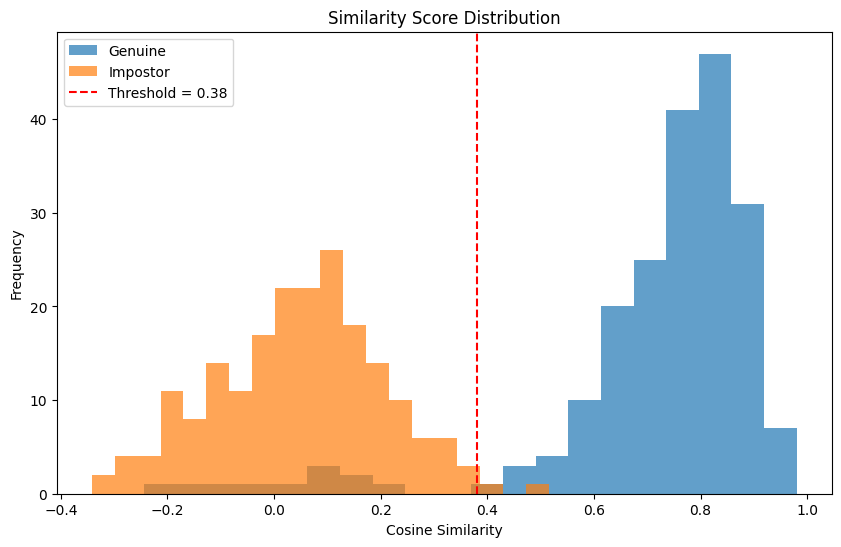

In [52]:
genuine_scores = [s for s, l in zip(scores, labels) if l == 1]
impostor_scores = [s for s, l in zip(scores, labels) if l == 0]

plt.figure(figsize=(10, 6))
plt.hist(genuine_scores, bins=20, alpha=0.7, label='Genuine')
plt.hist(impostor_scores, bins=20, alpha=0.7, label='Impostor')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Threshold = {best_threshold:.2f}')
plt.title("Similarity Score Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Plot FAR and FRR vs threshold

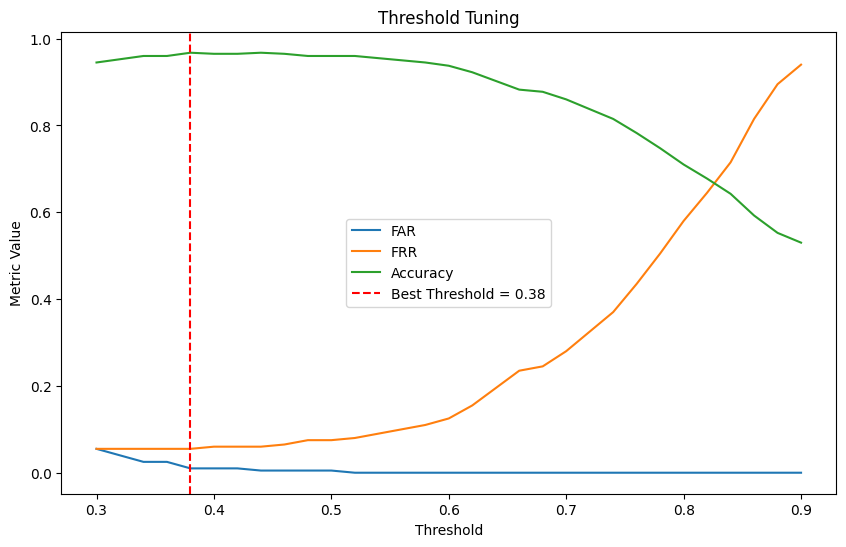

In [53]:
threshold_vals = [r[0] for r in results]
acc_vals = [r[1] for r in results]
far_vals = [r[2] for r in results]
frr_vals = [r[3] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(threshold_vals, far_vals, label="FAR")
plt.plot(threshold_vals, frr_vals, label="FRR")
plt.plot(threshold_vals, acc_vals, label="Accuracy")
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.title("Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.show()

ROC curve

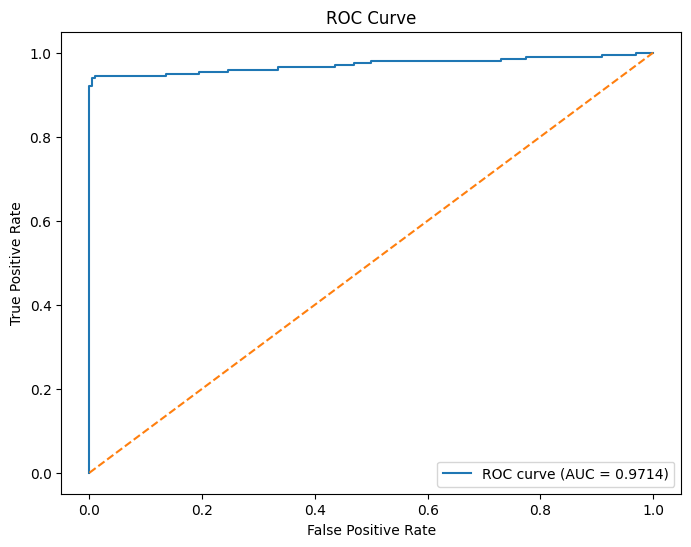

AUC: 0.9714


In [54]:
fpr, tpr, roc_thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("AUC:", round(roc_auc, 4))

Save Results

In [55]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Threshold", "Accuracy", "FAR", "FRR"])
results_df.to_csv("/content/lfw_threshold_results.csv", index=False)

summary_df = pd.DataFrame([{
    "Best_Threshold": best_threshold,
    "Accuracy": accuracy,
    "FAR": FAR,
    "FRR": FRR,
    "AUC": roc_auc,
    "Valid_Comparisons": len(scores),
    "Failed_Pairs": failed_pairs
}])

summary_df.to_csv("/content/lfw_final_summary.csv", index=False)

print("Saved:")
print("/content/lfw_threshold_results.csv")
print("/content/lfw_final_summary.csv")

Saved:
/content/lfw_threshold_results.csv
/content/lfw_final_summary.csv


Environmental Testing

In [56]:
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image

# --- Transformations ---
def apply_blur(img):
    return Image.fromarray(cv2.GaussianBlur(np.array(img), (11,11), 0))

def apply_brightness(img):
    return Image.fromarray(cv2.convertScaleAbs(np.array(img), alpha=1.0, beta=-60))

def apply_resolution(img):
    arr = np.array(img)
    small = cv2.resize(arr, (64,64))
    return Image.fromarray(cv2.resize(small, (arr.shape[1], arr.shape[0])))

# --- Embedding ---
def get_emb(img):
    face = mtcnn(img)
    if face is None:
        return None
    face = face.unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model(face)
    return emb.cpu().numpy().flatten()

# --- Evaluation ---
def run_env_test(pairs, mode="normal", thr=0.38):
    scores, labels, fail = [], [], 0

    for p1, p2, l in pairs:
        try:
            i1 = Image.open(p1).convert("RGB")
            i2 = Image.open(p2).convert("RGB")

            if mode == "blur":
                i1, i2 = apply_blur(i1), apply_blur(i2)
            elif mode == "brightness":
                i1, i2 = apply_brightness(i1), apply_brightness(i2)
            elif mode == "resolution":
                i1, i2 = apply_resolution(i1), apply_resolution(i2)

            e1, e2 = get_emb(i1), get_emb(i2)

            if e1 is None or e2 is None:
                fail += 1
                continue

            s = cosine_similarity(e1, e2)
            scores.append(s)
            labels.append(l)

        except:
            fail += 1

    preds = [1 if s >= thr else 0 for s in scores]

    TP = sum(p==1 and l==1 for p,l in zip(preds,labels))
    TN = sum(p==0 and l==0 for p,l in zip(preds,labels))
    FP = sum(p==1 and l==0 for p,l in zip(preds,labels))
    FN = sum(p==0 and l==1 for p,l in zip(preds,labels))

    acc = (TP+TN)/len(labels) if labels else 0
    FAR = FP/(FP+TN) if (FP+TN)>0 else 0
    FRR = FN/(FN+TP) if (FN+TP)>0 else 0

    return {"Condition":mode,"Accuracy":acc,"FAR":FAR,"FRR":FRR,
            "Valid":len(scores),"Failed":fail}

    Condition  Accuracy   FAR    FRR  Valid  Failed
0      normal    0.9675  0.01  0.055    400       0
1        blur    0.9450  0.02  0.090    400       0
2  brightness    0.9600  0.02  0.060    400       0
3  resolution    0.9500  0.02  0.080    400       0


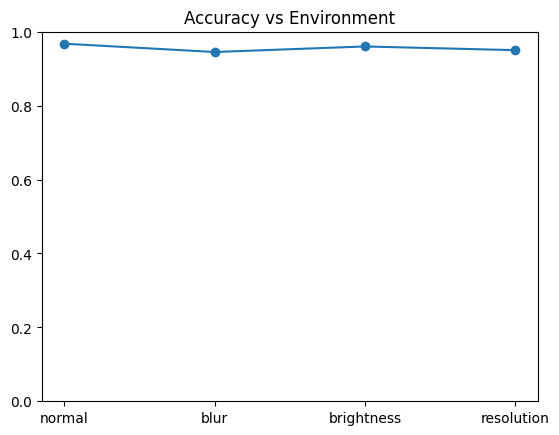

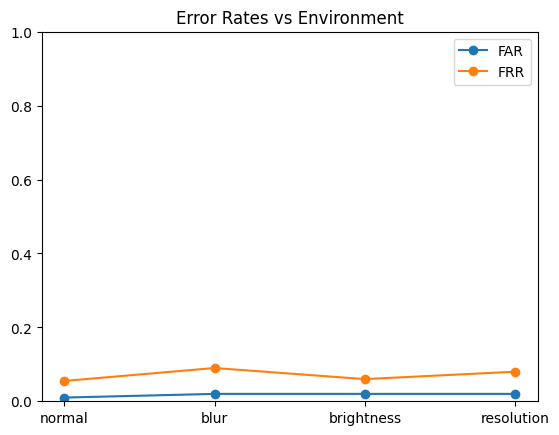

In [57]:
conditions = ["normal","blur","brightness","resolution"]

results = [run_env_test(pairs, c) for c in conditions]
df = pd.DataFrame(results)

print(df)

# --- Save ---
df.to_csv("/content/environment_results.csv", index=False)

# --- Plot Accuracy ---
plt.figure()
plt.plot(df["Condition"], df["Accuracy"], marker="o")
plt.title("Accuracy vs Environment")
plt.ylim(0,1)
plt.show()

# --- Plot FAR/FRR ---
plt.figure()
plt.plot(df["Condition"], df["FAR"], marker="o", label="FAR")
plt.plot(df["Condition"], df["FRR"], marker="o", label="FRR")
plt.legend()
plt.title("Error Rates vs Environment")
plt.ylim(0,1)
plt.show()

CelebA (Bias Analysis)

Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from numpy.linalg import norm

import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.metrics import roc_curve, auc

Set seed

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Paths

In [3]:
import os
import zipfile

zip_path = "/content/img_align_celeba.zip"
extract_path = "/content/celeba"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")
print(os.listdir(extract_path)[:10])

Extraction complete.
['img_align_celeba']


In [4]:
img_folder = "/content/celeba/img_align_celeba"
attr_path = "/content/list_attr_celeba.txt"
identity_path = "/content/identity_CelebA.txt"

print("Images folder exists:", os.path.exists(img_folder))
print("Attributes file exists:", os.path.exists(attr_path))
print("Identity file exists:", os.path.exists(identity_path))

Images folder exists: True
Attributes file exists: True
Identity file exists: True


Load CelebA attributes


In [5]:
df_attr = pd.read_csv(attr_path, sep=r"\s+", skiprows=1)
df_attr.index.name = "image_id"

print(df_attr.head())
print("Total attribute rows:", len(df_attr))

            5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
image_id                                                                     
000001.jpg                -1                1           1               -1   
000002.jpg                -1               -1          -1                1   
000003.jpg                -1               -1          -1               -1   
000004.jpg                -1               -1           1               -1   
000005.jpg                -1                1           1               -1   

            Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  \
image_id                                                             ...   
000001.jpg    -1     -1        -1        -1          -1          -1  ...   
000002.jpg    -1     -1        -1         1          -1          -1  ...   
000003.jpg    -1     -1         1        -1          -1          -1  ...   
000004.jpg    -1     -1        -1        -1          -1          -1  ... 

Load identity file

In [6]:
df_id = pd.read_csv(identity_path, sep=r"\s+", header=None, names=["image_id", "identity"])

print(df_id.head())
print("Total identity rows:", len(df_id))
print("Unique identities:", df_id["identity"].nunique())

     image_id  identity
0  000001.jpg      2880
1  000002.jpg      2937
2  000003.jpg      8692
3  000004.jpg      5805
4  000005.jpg      9295
Total identity rows: 202599
Unique identities: 10177


Merge attributes and identity

In [7]:
df = df_id.merge(df_attr, left_on="image_id", right_index=True, how="inner")

available_images = set([f for f in os.listdir(img_folder) if f.lower().endswith(".jpg")])
df = df[df["image_id"].isin(available_images)].copy()

print("Merged rows after filtering available images:", len(df))
print(df.head())

Merged rows after filtering available images: 202599
     image_id  identity  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0  000001.jpg      2880                -1                1           1   
1  000002.jpg      2937                -1               -1          -1   
2  000003.jpg      8692                -1               -1          -1   
3  000004.jpg      5805                -1               -1           1   
4  000005.jpg      9295                -1                1           1   

   Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  ...  Sideburns  Smiling  \
0               -1    -1     -1        -1        -1  ...         -1        1   
1                1    -1     -1        -1         1  ...         -1        1   
2               -1    -1     -1         1        -1  ...         -1       -1   
3               -1    -1     -1        -1        -1  ...         -1       -1   
4               -1    -1     -1         1        -1  ...         -1       -1   

   Straight_Hair  Wav

Keep only identities with at least 2 images

In [8]:
identity_counts = df["identity"].value_counts()
valid_ids = identity_counts[identity_counts >= 2].index

df_valid = df[df["identity"].isin(valid_ids)].copy()

print("Rows with valid identities:", len(df_valid))
print("Unique valid identities:", df_valid["identity"].nunique())

Rows with valid identities: 202555
Unique valid identities: 10133


Split into male and female subsets

CelebA uses:

Male = 1 → male
Male = -1 → female

In [9]:
male_df = df_valid[df_valid["Male"] == 1].copy()
female_df = df_valid[df_valid["Male"] == -1].copy()

print("Male rows:", len(male_df))
print("Female rows:", len(female_df))

print("Male identities:", male_df["identity"].nunique())
print("Female identities:", female_df["identity"].nunique())

Male rows: 84414
Female rows: 118141
Male identities: 5012
Female identities: 5736


Keep only subgroup identities with at least 2 images

In [10]:
male_id_counts = male_df["identity"].value_counts()
female_id_counts = female_df["identity"].value_counts()

male_valid_ids = male_id_counts[male_id_counts >= 2].index
female_valid_ids = female_id_counts[female_id_counts >= 2].index

male_df = male_df[male_df["identity"].isin(male_valid_ids)].copy()
female_df = female_df[female_df["identity"].isin(female_valid_ids)].copy()

print("Male usable identities:", male_df["identity"].nunique())
print("Female usable identities:", female_df["identity"].nunique())

Male usable identities: 4676
Female usable identities: 5662


Build pairs function

Each group gets:

one genuine pair per identity
one impostor pair per selected identity

In [18]:
def build_pairs_from_group(group_df):
    pairs = []

    grouped = group_df.groupby("identity")

    identity_list = list(grouped.groups.keys())

    # Genuine pairs
    for identity, rows in grouped:
        image_ids = rows["image_id"].tolist()
        if len(image_ids) >= 2:
            img1, img2 = random.sample(image_ids, 2)
            pairs.append((
                os.path.join(img_folder, img1),
                os.path.join(img_folder, img2),
                1
            ))

    # Impostor pairs
    for _ in range(len(identity_list)):
        id1, id2 = random.sample(identity_list, 2)

        img1 = random.choice(grouped.get_group(id1)["image_id"].tolist())
        img2 = random.choice(grouped.get_group(id2)["image_id"].tolist())

        pairs.append((
            os.path.join(img_folder, img1),
            os.path.join(img_folder, img2),
            0
        ))

    random.shuffle(pairs)
    return pairs

In [19]:
def build_pairs_from_group(group_df):
    import os
    import random

    pairs = []

    grouped = group_df.groupby("identity")
    identity_list = list(grouped.groups.keys())

    # -------------------
    # Genuine pairs
    # -------------------
    for identity, rows in grouped:
        image_ids = rows["image_id"].tolist()
        if len(image_ids) >= 2:
            img1, img2 = random.sample(image_ids, 2)
            pairs.append((
                os.path.join("/content/celeba/img_align_celeba", img1),
                os.path.join("/content/celeba/img_align_celeba", img2),
                1
            ))

    # -------------------
    # Impostor pairs
    # -------------------
    for _ in range(len(identity_list)):
        id1, id2 = random.sample(identity_list, 2)

        img1 = random.choice(grouped.get_group(id1)["image_id"].tolist())
        img2 = random.choice(grouped.get_group(id2)["image_id"].tolist())

        pairs.append((
            os.path.join("/content/celeba/img_align_celeba", img1),
            os.path.join("/content/celeba/img_align_celeba", img2),
            0
        ))

    random.shuffle(pairs)
    return pairs

In [22]:
import os, random, pandas as pd

# -----------------------------
# Paths
# -----------------------------
img_folder = "/content/celeba/img_align_celeba"
attr_path = "/content/list_attr_celeba.txt"
identity_path = "/content/identity_CelebA.txt"

# -----------------------------
# Load data
# -----------------------------
df_attr = pd.read_csv(attr_path, sep=r"\s+", skiprows=1)
df_attr.index.name = "image_id"

df_id = pd.read_csv(identity_path, sep=r"\s+", header=None, names=["image_id", "identity"])

df = df_id.merge(df_attr, left_on="image_id", right_index=True, how="inner")

available_images = set(f for f in os.listdir(img_folder) if f.endswith(".jpg"))
df = df[df["image_id"].isin(available_images)].copy()

# -----------------------------
# Keep valid identities (>=2 images)
# -----------------------------
counts = df["identity"].value_counts()
valid_ids = counts[counts >= 2].index
df_valid = df[df["identity"].isin(valid_ids)].copy()

# -----------------------------
# Split male/female
# -----------------------------
male_df = df_valid[df_valid["Male"] == 1].copy()
female_df = df_valid[df_valid["Male"] == -1].copy()

# -----------------------------
# Filter subgroup identities (>=2 images)
# -----------------------------
male_counts = male_df["identity"].value_counts()
female_counts = female_df["identity"].value_counts()

male_df = male_df[male_df["identity"].isin(male_counts[male_counts >= 2].index)]
female_df = female_df[female_df["identity"].isin(female_counts[female_counts >= 2].index)]

# -----------------------------
# Sample identities safely
# -----------------------------
sample_size = min(200, male_df["identity"].nunique(), female_df["identity"].nunique())

male_ids = random.sample(list(male_df["identity"].unique()), sample_size)
female_ids = random.sample(list(female_df["identity"].unique()), sample_size)

male_sample_df = male_df[male_df["identity"].isin(male_ids)]
female_sample_df = female_df[female_df["identity"].isin(female_ids)]

print("Male identities:", male_sample_df["identity"].nunique())
print("Female identities:", female_sample_df["identity"].nunique())

# -----------------------------
# Build pairs function
# -----------------------------
def build_pairs(group_df):
    pairs = []
    grouped = group_df.groupby("identity")
    ids = list(grouped.groups.keys())

    # Genuine
    for identity, rows in grouped:
        imgs = rows["image_id"].tolist()
        if len(imgs) >= 2:
            i1, i2 = random.sample(imgs, 2)
            pairs.append((os.path.join(img_folder, i1),
                          os.path.join(img_folder, i2),
                          1))

    # Impostor
    for _ in range(len(ids)):
        id1, id2 = random.sample(ids, 2)
        img1 = random.choice(grouped.get_group(id1)["image_id"].tolist())
        img2 = random.choice(grouped.get_group(id2)["image_id"].tolist())

        pairs.append((os.path.join(img_folder, img1),
                      os.path.join(img_folder, img2),
                      0))

    random.shuffle(pairs)
    return pairs

# -----------------------------
# Create pairs
# -----------------------------
male_pairs = build_pairs(male_sample_df)
female_pairs = build_pairs(female_sample_df)

print("Male pairs:", len(male_pairs))
print("Female pairs:", len(female_pairs))

print("Male genuine:", sum(1 for _, _, l in male_pairs if l == 1))
print("Male impostor:", sum(1 for _, _, l in male_pairs if l == 0))

print("Female genuine:", sum(1 for _, _, l in female_pairs if l == 1))
print("Female impostor:", sum(1 for _, _, l in female_pairs if l == 0))

Male identities: 200
Female identities: 200
Male pairs: 400
Female pairs: 400
Male genuine: 200
Male impostor: 200
Female genuine: 200
Female impostor: 200


Load FaceNet model and detector

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

mtcnn = MTCNN(image_size=160, margin=0, device=device)
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

Using device: cuda


  0%|          | 0.00/107M [00:00<?, ?B/s]

Embedding function

In [24]:
def get_embedding(img_path):
    try:
        img = Image.open(img_path).convert("RGB")
        face = mtcnn(img)

        if face is None:
            return None

        face = face.unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = model(face)

        return embedding.cpu().numpy().flatten()

    except Exception:
        return None

Cached embeddings

In [25]:
embedding_cache = {}

def get_cached_embedding(img_path):
    if img_path not in embedding_cache:
        embedding_cache[img_path] = get_embedding(img_path)
    return embedding_cache[img_path]

Cosine similarity

In [26]:
def cosine_similarity(a, b):
    a = np.squeeze(a)
    b = np.squeeze(b)
    return np.dot(a, b) / (norm(a) * norm(b))

Evaluate one pair set

In [27]:
def compute_scores_and_labels(pairs):
    scores = []
    labels = []
    failed_pairs = 0

    for img1, img2, label in pairs:
        emb1 = get_cached_embedding(img1)
        emb2 = get_cached_embedding(img2)

        if emb1 is None or emb2 is None:
            failed_pairs += 1
            continue

        sim = cosine_similarity(emb1, emb2)
        scores.append(float(sim))
        labels.append(label)

    return scores, labels, failed_pairs

Threshold tuning function

In [28]:
def tune_threshold(scores, labels, thresholds=np.arange(0.30, 0.91, 0.02)):
    results = []
    best_acc = 0
    best_threshold = None

    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]

        TP = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 1)
        TN = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 0)
        FP = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 0)
        FN = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 1)

        acc = (TP + TN) / len(labels)
        FAR = FP / (FP + TN) if (FP + TN) > 0 else 0
        FRR = FN / (FN + TP) if (FN + TP) > 0 else 0

        results.append((t, acc, FAR, FRR))

        if acc > best_acc:
            best_acc = acc
            best_threshold = t

    return best_threshold, best_acc, results

Final metrics function

In [29]:
def compute_final_metrics(scores, labels, threshold):
    preds = [1 if s >= threshold else 0 for s in scores]

    TP = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 1)
    TN = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 0)
    FP = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 0)
    FN = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 1)

    accuracy = (TP + TN) / len(labels)
    FAR = FP / (FP + TN) if (FP + TN) > 0 else 0
    FRR = FN / (FN + TP) if (FN + TP) > 0 else 0

    return {
        "Accuracy": accuracy,
        "FAR": FAR,
        "FRR": FRR,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    }

Run male evaluation

In [30]:
male_scores, male_labels, male_failed = compute_scores_and_labels(male_pairs)

print("Male valid comparisons:", len(male_scores))
print("Male failed pairs:", male_failed)

male_best_threshold, male_best_acc, male_threshold_results = tune_threshold(male_scores, male_labels)

male_metrics = compute_final_metrics(male_scores, male_labels, male_best_threshold)

print("Male best threshold:", round(male_best_threshold, 2))
print("Male metrics:", male_metrics)

Male valid comparisons: 398
Male failed pairs: 2
Male best threshold: 0.36
Male metrics: {'Accuracy': 0.9698492462311558, 'FAR': 0.010050251256281407, 'FRR': 0.05025125628140704, 'TP': 189, 'TN': 197, 'FP': 2, 'FN': 10}


Run female evaluation

In [31]:
female_scores, female_labels, female_failed = compute_scores_and_labels(female_pairs)

print("Female valid comparisons:", len(female_scores))
print("Female failed pairs:", female_failed)

female_best_threshold, female_best_acc, female_threshold_results = tune_threshold(female_scores, female_labels)

female_metrics = compute_final_metrics(female_scores, female_labels, female_best_threshold)

print("Female best threshold:", round(female_best_threshold, 2))
print("Female metrics:", female_metrics)

Female valid comparisons: 400
Female failed pairs: 0
Female best threshold: 0.36
Female metrics: {'Accuracy': 0.945, 'FAR': 0.025, 'FRR': 0.085, 'TP': 183, 'TN': 195, 'FP': 5, 'FN': 17}


Build summary table

In [32]:
summary_df = pd.DataFrame([
    {
        "Group": "Male",
        "Valid_Comparisons": len(male_scores),
        "Failed_Pairs": male_failed,
        "Best_Threshold": male_best_threshold,
        "Accuracy": male_metrics["Accuracy"],
        "FAR": male_metrics["FAR"],
        "FRR": male_metrics["FRR"],
        "TP": male_metrics["TP"],
        "TN": male_metrics["TN"],
        "FP": male_metrics["FP"],
        "FN": male_metrics["FN"]
    },
    {
        "Group": "Female",
        "Valid_Comparisons": len(female_scores),
        "Failed_Pairs": female_failed,
        "Best_Threshold": female_best_threshold,
        "Accuracy": female_metrics["Accuracy"],
        "FAR": female_metrics["FAR"],
        "FRR": female_metrics["FRR"],
        "TP": female_metrics["TP"],
        "TN": female_metrics["TN"],
        "FP": female_metrics["FP"],
        "FN": female_metrics["FN"]
    }
])

summary_df

,Group,Valid_Comparisons,Failed_Pairs,Best_Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN
0,Male,398,2,0.36,0.969849,0.01005,0.050251,189,197,2,10
1,Female,400,0,0.36,0.945000,0.02500,0.085000,183,195,5,17


Save summary

In [33]:
summary_df.to_csv("/content/celeba_gender_bias_summary.csv", index=False)
print("Saved: /content/celeba_gender_bias_summary.csv")

Saved: /content/celeba_gender_bias_summary.csv


Accuracy / FAR / FRR bar charts

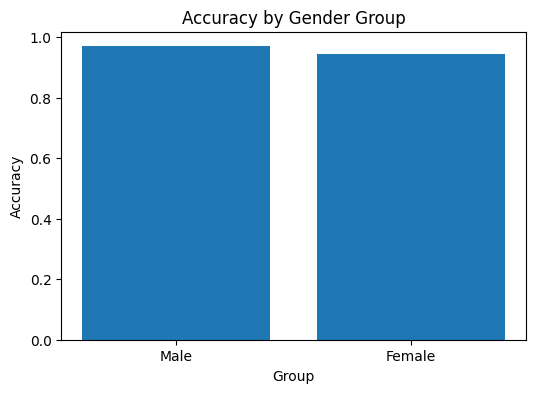

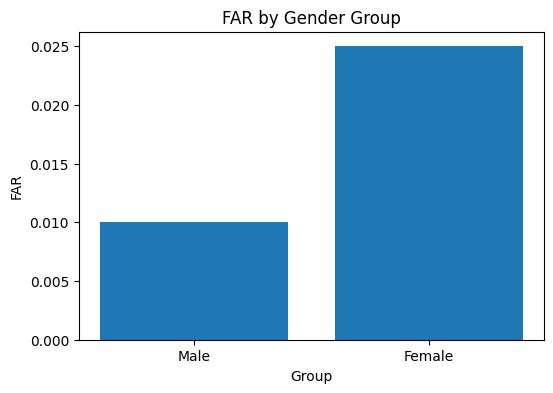

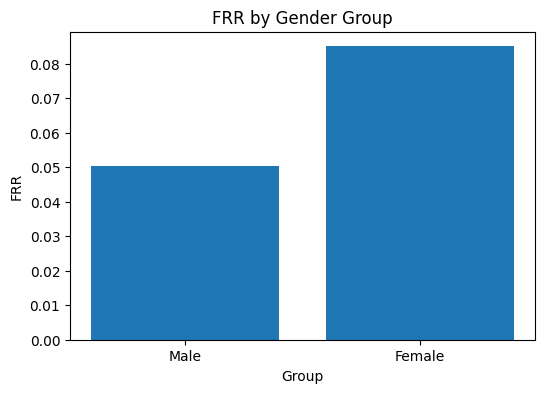

In [34]:
metrics_to_plot = ["Accuracy", "FAR", "FRR"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(summary_df["Group"], summary_df[metric])
    plt.title(f"{metric} by Gender Group")
    plt.xlabel("Group")
    plt.ylabel(metric)
    plt.show()

Score distributions

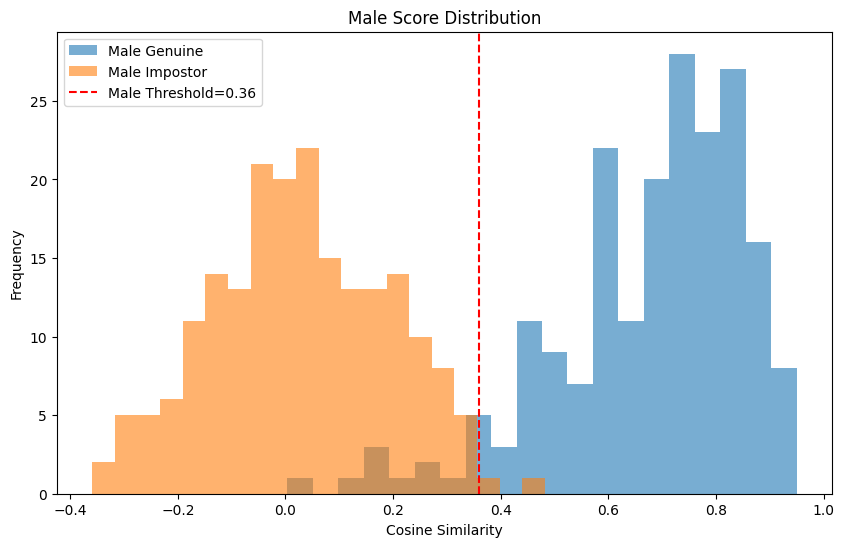

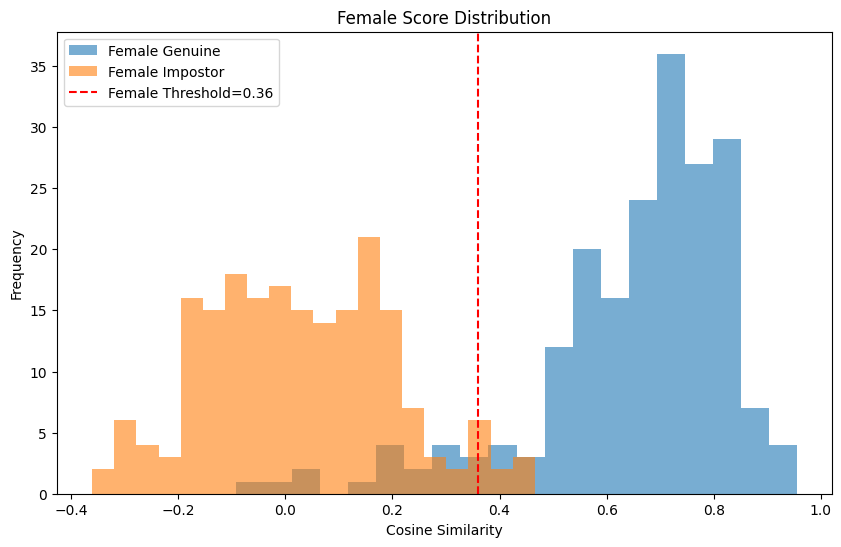

In [35]:
plt.figure(figsize=(10, 6))
plt.hist([s for s, l in zip(male_scores, male_labels) if l == 1], bins=20, alpha=0.6, label="Male Genuine")
plt.hist([s for s, l in zip(male_scores, male_labels) if l == 0], bins=20, alpha=0.6, label="Male Impostor")
plt.axvline(male_best_threshold, color="red", linestyle="--", label=f"Male Threshold={male_best_threshold:.2f}")
plt.title("Male Score Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist([s for s, l in zip(female_scores, female_labels) if l == 1], bins=20, alpha=0.6, label="Female Genuine")
plt.hist([s for s, l in zip(female_scores, female_labels) if l == 0], bins=20, alpha=0.6, label="Female Impostor")
plt.axvline(female_best_threshold, color="red", linestyle="--", label=f"Female Threshold={female_best_threshold:.2f}")
plt.title("Female Score Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Save threshold tuning details

In [36]:
male_threshold_df = pd.DataFrame(male_threshold_results, columns=["Threshold", "Accuracy", "FAR", "FRR"])
female_threshold_df = pd.DataFrame(female_threshold_results, columns=["Threshold", "Accuracy", "FAR", "FRR"])

male_threshold_df.to_csv("/content/male_threshold_results.csv", index=False)
female_threshold_df.to_csv("/content/female_threshold_results.csv", index=False)

print("Saved:")
print("/content/male_threshold_results.csv")
print("/content/female_threshold_results.csv")

Saved:
/content/male_threshold_results.csv
/content/female_threshold_results.csv
